# PDL Challenge 2: Dropout, Sparsification and Ensembles with VGG16 on CIFAR-10

Colab notebook. Use `Runtime > Change runtime type > GPU`, then `Runtime > Run all`.

Outline

1. Data and the frozen VGG16 convolutional base
2. Reliability metric: P(j|i), Q(j|i) and the conditional KL divergence
3. Baseline model and the accuracy vs reliability curve (Sec. 3, 3.1)
4. Task 1: ensemble of 5 models with 80% of the dense-layer nodes removed (Sec. 4)
5. Task 2: ensemble of 5 models with 80% of the dense-layer edges removed (Sec. 5)
6. Summary

Because the convolutional layers are frozen and there is no data augmentation, the VGG16 output for every
image never changes. The 512-d pooled features are therefore computed once, and all dense heads are trained
on these cached features. This is mathematically the same model as in the handout (checked in Section 3),
but training the many heads becomes much faster.

In [1]:
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print('TensorFlow', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

# ---------------- configuration ----------------
SEED = 42
BASE_WEIGHTS = 'imagenet'    # the handout uses None; with frozen random conv layers ~70% accuracy is not reachable
NUM_CLASSES = 10
VAL_SIZE = 5000              # held out from the training set, used only to choose the temperature

BASELINE_LR = 1e-4
BASELINE_MAX_EPOCHS = 30
BASELINE_TARGET_ACC = 0.70   # stop the baseline once validation accuracy reaches this (None = train all epochs)
EVAL_EVERY = 25              # training steps between two reliability evaluations of the baseline

N_MEMBERS = 5
KEEP_FRACTION = 0.2          # keep 20% of the nodes (Task 1) / edges (Task 2)
INIT_FROM_BASELINE = True    # members start from the baseline weights, then are retrained after masking
MEMBER_LR = 1e-3
MEMBER_EPOCHS = 10
BATCH_SIZE = 256             # large enough that every class appears in a batch (needed by the KL loss)

KL_LAMBDA = 1.0              # weight of the conditional KL term in the loss
L2_WEIGHT = 1e-4             # L2 penalty on the dense kernels
CONF_BETA = 1.0              # weight of the confidence-branch loss
TEMPERATURE_CRITERION = 'cond_kl'  # metric minimised on the validation set when choosing T ('cond_kl' or 'nll')

SAVE_TO_DRIVE = False
RESULTS_DIR = '/content/drive/MyDrive/PDL_CA2' if SAVE_TO_DRIVE else '/content/PDL_CA2'

keras.utils.set_random_seed(SEED)
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
os.makedirs(RESULTS_DIR, exist_ok=True)

TensorFlow 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Data and the frozen VGG16 convolutional base

In [2]:
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.cifar10.load_data()
y_train_full, y_test = y_train_full.ravel(), y_test.ravel()
CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

perm = np.random.default_rng(SEED).permutation(len(x_train_full))
val_idx, train_idx = perm[:VAL_SIZE], perm[VAL_SIZE:]
x_train, y_train = x_train_full[train_idx], y_train_full[train_idx]
x_val, y_val = x_train_full[val_idx], y_train_full[val_idx]

base_model = keras.applications.VGG16(include_top=False, input_shape=(32, 32, 3),
                                      weights=BASE_WEIGHTS, pooling='avg')
base_model.trainable = False


def preprocess(x):
    return keras.applications.vgg16.preprocess_input(x.astype('float32'))


def extract_features(x):
    return base_model.predict(preprocess(x), batch_size=512, verbose=0)


t0 = time.time()
F_train, F_val, F_test = (extract_features(x) for x in (x_train, x_val, x_test))
Y_train, Y_val, Y_test = (keras.utils.to_categorical(y, NUM_CLASSES) for y in (y_train, y_val, y_test))
FEAT_DIM = F_train.shape[1]
print(f'features: train {F_train.shape}, val {F_val.shape}, test {F_test.shape} ({time.time() - t0:.0f}s)')

# fixed subset of the training set, used to measure train accuracy (over-fitting)
train_eval_idx = np.random.default_rng(SEED).choice(len(F_train), 10000, replace=False)
F_train_eval, y_train_eval = F_train[train_eval_idx], y_train[train_eval_idx]

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 80s 0us/step
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
features: train (45000, 512), val (5000, 512), test (10000, 512) (36s)


## 2. Reliability metric (Sec. 1.2 and 3.1)

For a set of weights and a test set:

1. `P[i, j]` = fraction of test inputs of true class i that the model assigns to class j (each row sums to 1).
2. `Q[i, j]` = average softmax output j over the test inputs of true class i (each row sums to 1).
3. Per-class KL, Eq. (1): `D_KL(P(.|i) || Q(.|i)) = sum_j P[i, j] log(P[i, j] / Q[i, j])`.
4. Conditional KL, Eq. (2): the per-class KL averaged with weights `P(i)`, the true-label distribution. One scalar; lower means more reliable.

We also report the mean confidence (average of the max softmax output). A model is overconfident when its mean
confidence is higher than its accuracy.

In [3]:
def softmax_np(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)


def reliability_matrices(probs, y_true, n_classes=NUM_CLASSES):
    '''Returns P (empirical prediction distribution), Q (mean softmax) and the true-label prior.'''
    pred = probs.argmax(axis=1)
    P = np.zeros((n_classes, n_classes))
    Q = np.zeros((n_classes, n_classes))
    prior = np.zeros(n_classes)
    for i in range(n_classes):
        idx = y_true == i
        prior[i] = idx.mean()
        P[i] = np.bincount(pred[idx], minlength=n_classes) / idx.sum()
        Q[i] = probs[idx].mean(axis=0)
    return P, Q, prior


def kl_per_class(P, Q, eps=1e-12):
    '''Eq. (1) applied to every row: D_KL(P(.|i) || Q(.|i)).'''
    terms = np.where(P > 0, P * np.log((P + eps) / (Q + eps)), 0.0)
    return terms.sum(axis=1)


def conditional_kl(P, Q, prior):
    '''Eq. (2): per-class KL averaged over the true-label distribution.'''
    return float(prior @ kl_per_class(P, Q))


def evaluate_probs(probs, y_true):
    P, Q, prior = reliability_matrices(probs, y_true)
    return {
        'accuracy': float((probs.argmax(axis=1) == y_true).mean()),
        'cond_kl': conditional_kl(P, Q, prior),
        'mean_conf': float(probs.max(axis=1).mean()),
        'nll': float(-np.mean(np.log(probs[np.arange(len(y_true)), y_true] + 1e-12))),
    }


def plot_reliability(probs, y_true, title):
    P, Q, prior = reliability_matrices(probs, y_true)
    fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))
    for ax, M, name in zip(axes[:2], (P, Q), ('P(j|i): empirical prediction', 'Q(j|i): mean softmax')):
        ax.imshow(M, cmap='Blues', vmin=0, vmax=1)
        for i in range(NUM_CLASSES):
            for j in range(NUM_CLASSES):
                ax.text(j, i, f'{M[i, j]:.2f}', ha='center', va='center', fontsize=7,
                        color='white' if M[i, j] > 0.5 else 'black')
        ax.set_xticks(range(NUM_CLASSES), CLASS_NAMES, rotation=45, ha='right')
        ax.set_yticks(range(NUM_CLASSES), CLASS_NAMES)
        ax.set_xlabel('predicted label j')
        ax.set_ylabel('true label i')
        ax.set_title(name)
    axes[2].bar(CLASS_NAMES, kl_per_class(P, Q))
    axes[2].tick_params(axis='x', rotation=45)
    axes[2].set_ylabel('D_KL(P(.|i) || Q(.|i))')
    axes[2].set_title(f'per-class KL, conditional KL = {conditional_kl(P, Q, prior):.4f}')
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

## Model building blocks

* `NodeMask` (Task 1): multiplies the activations of a dense layer by a fixed random 0/1 mask, so 80% of its
  nodes are removed permanently. This is one dropout sample frozen for the whole life of the member.
* `MaskedDense` (Task 2): a dense layer whose kernel is multiplied by a fixed random 0/1 mask, so 80% of its
  edges are removed (random sparsification). Masked weights receive zero gradient.
* Loss: categorical cross-entropy, optionally plus
  * `KL_LAMBDA * conditional KL` computed on the mini-batch (P is built from the argmax and treated as a
    constant, the gradient flows through Q), and
  * `CONF_BETA * BCE(c, 1[prediction is correct])` for heads with a confidence branch.
* Confidence branch: an extra `Dense(64) -> Dense(1, sigmoid)` output `c` on top of the last hidden layer,
  trained to predict whether the classification is correct. At inference the class probabilities are mixed
  with the uniform distribution: `p' = c * p + (1 - c) / 10`, so a low `c` lowers the confidence without
  changing the predicted class.

In [4]:
class NodeMask(layers.Layer):
    '''Multiplies the activations by a fixed 0/1 mask: the dropped nodes are removed for good.'''

    def __init__(self, keep_fraction, seed, **kwargs):
        super().__init__(**kwargs)
        self.keep_fraction, self.seed = keep_fraction, seed

    def build(self, input_shape):
        n = int(input_shape[-1])
        mask = np.zeros(n, 'float32')
        mask[np.random.default_rng(self.seed).choice(n, int(round(self.keep_fraction * n)), replace=False)] = 1.0
        self.keep_mask = self.add_weight(name='keep_mask', shape=(n,), initializer='zeros', trainable=False)
        self.keep_mask.assign(mask)

    def call(self, x):
        return x * self.keep_mask

    def compute_output_shape(self, input_shape):
        return input_shape


class MaskedDense(layers.Layer):
    '''Dense layer whose kernel is multiplied by a fixed 0/1 mask (random sparsification).'''

    def __init__(self, units, keep_fraction, seed, activation=None, kernel_regularizer=None, **kwargs):
        super().__init__(**kwargs)
        self.units, self.keep_fraction, self.seed = units, keep_fraction, seed
        self.activation = keras.activations.get(activation)
        self.kernel_regularizer = kernel_regularizer

    def build(self, input_shape):
        n_in = int(input_shape[-1])
        self.kernel = self.add_weight(name='kernel', shape=(n_in, self.units), initializer='glorot_uniform',
                                      regularizer=self.kernel_regularizer)
        self.bias = self.add_weight(name='bias', shape=(self.units,), initializer='zeros')
        self.keep_mask = self.add_weight(name='keep_mask', shape=(n_in, self.units), initializer='zeros',
                                         trainable=False)
        n_edges = n_in * self.units
        mask = np.zeros(n_edges, 'float32')
        mask[np.random.default_rng(self.seed).choice(n_edges, int(round(self.keep_fraction * n_edges)),
                                                     replace=False)] = 1.0
        self.keep_mask.assign(mask.reshape(n_in, self.units))

    def call(self, x):
        return self.activation(tf.matmul(x, self.kernel * self.keep_mask) + self.bias)

    def compute_output_shape(self, input_shape):
        return (*input_shape[:-1], self.units)


def build_head(kind='baseline', seed=0, keep_fraction=KEEP_FRACTION, l2=0.0, conf_branch=False, name=None):
    '''Dense part of the modified VGG16: 512 -> 256 -> 10. kind is 'baseline', 'node' (Task 1) or 'edge' (Task 2).'''
    reg = keras.regularizers.l2(l2) if l2 else None

    def dense(units, lname, activation, k):
        if kind == 'edge':
            return MaskedDense(units, keep_fraction, seed=seed * 100 + k, activation=activation,
                               kernel_regularizer=reg, name=lname)
        return layers.Dense(units, activation=activation, kernel_regularizer=reg, name=lname)

    inp = keras.Input(shape=(FEAT_DIM,), name='features')
    x = dense(512, 'fc1', 'relu', 1)(inp)
    if kind == 'node':
        x = NodeMask(keep_fraction, seed * 100 + 1, name='mask1')(x)
    x = dense(256, 'fc2', 'relu', 2)(x)
    if kind == 'node':
        x = NodeMask(keep_fraction, seed * 100 + 2, name='mask2')(x)
    logits = dense(NUM_CLASSES, 'logits', None, 3)(x)
    out = layers.Softmax(name='probs')(logits)
    if conf_branch:
        c = layers.Dense(64, activation='relu', name='conf_hidden')(x)
        c = layers.Dense(1, activation='sigmoid', name='conf')(c)
        out = layers.Concatenate(name='probs_conf')([out, c])
    return keras.Model(inp, out, name=name or f'{kind}_head_{seed}')


def copy_head_weights(src, dst):
    for lname in ('fc1', 'fc2', 'logits'):
        s, d = src.get_layer(lname), dst.get_layer(lname)
        d.kernel.assign(s.kernel)
        d.bias.assign(s.bias)


def active_weights(model):
    '''Number of weights + biases that can still influence the output after masking.'''
    names = {l.name for l in model.layers}
    keep_in, total = np.ones(FEAT_DIM), 0.0
    for lname, mname in (('fc1', 'mask1'), ('fc2', 'mask2'), ('logits', None)):
        layer = model.get_layer(lname)
        W = layer.keep_mask.numpy() if isinstance(layer, MaskedDense) else np.ones(tuple(layer.kernel.shape))
        keep_out = model.get_layer(mname).keep_mask.numpy() if mname in names else np.ones(W.shape[1])
        total += (W * keep_in[:, None] * keep_out[None, :]).sum() + keep_out.sum()
        keep_in = keep_out
    return int(total)


def batch_conditional_kl(y_true, probs, eps=1e-7):
    '''Differentiable Eq. (2) on one mini-batch. P comes from the argmax and is treated as a constant.'''
    pred_onehot = tf.stop_gradient(tf.one_hot(tf.argmax(probs, axis=-1), NUM_CLASSES, dtype=probs.dtype))
    counts = tf.reduce_sum(y_true, axis=0)
    P = tf.matmul(y_true, pred_onehot, transpose_a=True) / (counts[:, None] + eps)
    Q = tf.matmul(y_true, probs, transpose_a=True) / (counts[:, None] + eps)
    prior = counts / tf.reduce_sum(counts)
    kl_rows = tf.reduce_sum(P * (tf.math.log(P + eps) - tf.math.log(Q + eps)), axis=-1)
    return tf.reduce_sum(prior * kl_rows)


def make_loss(kl_lambda=0.0, conf_beta=0.0):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, y_pred.dtype)
        probs = y_pred[:, :NUM_CLASSES]
        total = keras.losses.categorical_crossentropy(y_true, probs)
        if kl_lambda:
            total = total + kl_lambda * batch_conditional_kl(y_true, probs)
        if conf_beta:
            correct = tf.cast(tf.equal(tf.argmax(probs, -1), tf.argmax(y_true, -1)), y_pred.dtype)
            total = total + conf_beta * keras.losses.binary_crossentropy(correct[:, None], y_pred[:, NUM_CLASSES:])
        return total
    return loss


def cls_acc(y_true, y_pred):
    return tf.cast(tf.equal(tf.argmax(y_true, -1), tf.argmax(y_pred[:, :NUM_CLASSES], -1)), tf.float32)


def run(model, X, batch=8192):
    return np.concatenate([np.asarray(model(X[i:i + batch], training=False)) for i in range(0, len(X), batch)])


def outputs_to_probs(out):
    '''Heads with a confidence branch output [p (10), c (1)]; mix p with the uniform distribution using c.'''
    if out.shape[1] == NUM_CLASSES:
        return out
    p, c = out[:, :NUM_CLASSES], out[:, NUM_CLASSES:]
    return c * p + (1.0 - c) / NUM_CLASSES


def predict_probs(model, X, temperature=1.0):
    if temperature == 1.0:
        return outputs_to_probs(run(model, X))
    logit_model = keras.Model(model.input, model.get_layer('logits').output)
    return softmax_np(run(logit_model, X) / temperature)


def ensemble_probs(members, X, temperature=1.0):
    return np.mean([predict_probs(m, X, temperature) for m in members], axis=0)

## 3. Baseline model (Sec. 3) and accuracy vs reliability (Sec. 3.1)

Only the three dense layers are trained. Every `EVAL_EVERY` steps the accuracy, the mean confidence and the
conditional KL are measured on the test set, so we can follow how reliability evolves during training.
Training stops once the validation accuracy reaches `BASELINE_TARGET_ACC` (about 70%, as in the handout).

In [5]:
class ReliabilityTracker(keras.callbacks.Callback):
    '''Evaluates accuracy, mean confidence and conditional KL on (X, y) every `every` training steps.'''

    def __init__(self, X, y, every, steps_per_epoch):
        super().__init__()
        self.X, self.y, self.every, self.steps_per_epoch = X, y, every, steps_per_epoch
        self.records, self.step = [], 0

    def _record(self):
        metrics = evaluate_probs(outputs_to_probs(run(self.model, self.X)), self.y)
        self.records.append({'epoch': self.step / self.steps_per_epoch, **metrics})

    def on_train_begin(self, logs=None):
        self._record()

    def on_train_batch_end(self, batch, logs=None):
        self.step += 1
        if self.step % self.every == 0:
            self._record()


class StopAtAccuracy(keras.callbacks.Callback):
    def __init__(self, target):
        super().__init__()
        self.target = target

    def on_epoch_end(self, epoch, logs=None):
        if self.target is not None and logs.get('val_cls_acc', 0.0) >= self.target:
            print(f'validation accuracy {logs["val_cls_acc"]:.4f} >= {self.target}, stopping after epoch {epoch + 1}')
            self.model.stop_training = True


baseline = build_head('baseline', name='baseline_head')
baseline.compile(optimizer=keras.optimizers.Adam(BASELINE_LR), loss=make_loss(), metrics=[cls_acc])
baseline.summary()

steps_per_epoch = int(np.ceil(len(F_train) / BATCH_SIZE))
tracker = ReliabilityTracker(F_test, y_test, EVAL_EVERY, steps_per_epoch)
baseline_hist = baseline.fit(F_train, Y_train, validation_data=(F_val, Y_val), epochs=BASELINE_MAX_EPOCHS,
                             batch_size=BATCH_SIZE, callbacks=[tracker, StopAtAccuracy(BASELINE_TARGET_ACC)],
                             verbose=2)

baseline_curve = pd.DataFrame(tracker.records)
baseline_probs = predict_probs(baseline, F_test)
print('baseline on the test set:', {k: round(v, 4) for k, v in evaluate_probs(baseline_probs, y_test).items()})

Model: "baseline_head"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features (InputLayer)           │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, 10)             │         2,570 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ probs (Softmax)                 │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 396,554 (1.51 MB)

 Trainable params: 396,554 (1.51 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
176/176 - 5s - 28ms/step - cls_acc: 0.4335 - loss: 3.4160 - val_cls_acc: 0.5062 - val_loss: 2.2702
Epoch 2/30
176/176 - 1s - 4ms/step - cls_acc: 0.5565 - loss: 1.7882 - val_cls_acc: 0.5482 - val_loss: 1.8060
Epoch 3/30
176/176 - 1s - 4ms/step - cls_acc: 0.6070 - loss: 1.3976 - val_cls_acc: 0.5742 - val_loss: 1.6195
Epoch 4/30
176/176 - 1s - 4ms/step - cls_acc: 0.6499 - loss: 1.1759 - val_cls_acc: 0.5842 - val_loss: 1.5270
Epoch 5/30
176/176 - 1s - 4ms/step - cls_acc: 0.6848 - loss: 1.0208 - val_cls_acc: 0.5904 - val_loss: 1.4677
Epoch 6/30
176/176 - 1s - 4ms/step - cls_acc: 0.7156 - loss: 0.9027 - val_cls_acc: 0.5970 - val_loss: 1.4274
Epoch 7/30
176/176 - 1s - 4ms/step - cls_acc: 0.7434 - loss: 0.8079 - val_cls_acc: 0.6012 - val_loss: 1.3995
Epoch 8/30
176/176 - 1s - 4ms/step - cls_acc: 0.7691 - loss: 0.7293 - val_cls_acc: 0.6078 - val_loss: 1.3800
Epoch 9/30
176/176 - 1s - 4ms/step - cls_acc: 0.7900 - loss: 0.6618 - val_cls_acc: 0.6140 - val_loss: 1.3671
Epoch 10/30
176/17

Check that the dense head trained on cached features is the same network as the full model of the handout
(frozen VGG16 base, Flatten, three dense layers).

In [6]:
full_model = keras.Sequential([keras.Input(shape=(32, 32, 3)), base_model, layers.Flatten(), baseline],
                              name='modified_vgg16')
full_model.summary()

x_check = preprocess(x_test[:256])
diff = np.abs(full_model.predict(x_check, verbose=0) - baseline.predict(F_test[:256], verbose=0)).max()
print(f'max |full model - head on cached features| = {diff:.2e}')

Model: "modified_vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 512)            │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ baseline_head (Functional)      │ (None, 10)             │       396,554 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,111,242 (57.64 MB)

 Trainable params: 396,554 (1.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

max |full model - head on cached features| = 5.01e-06


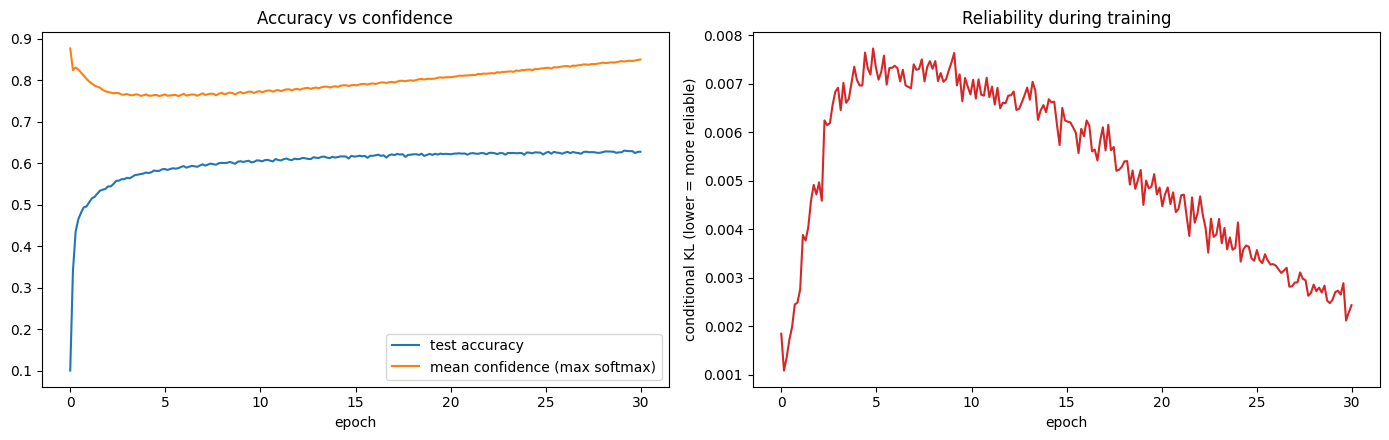

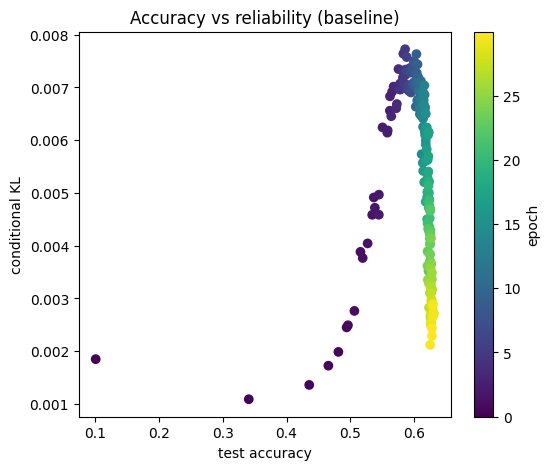

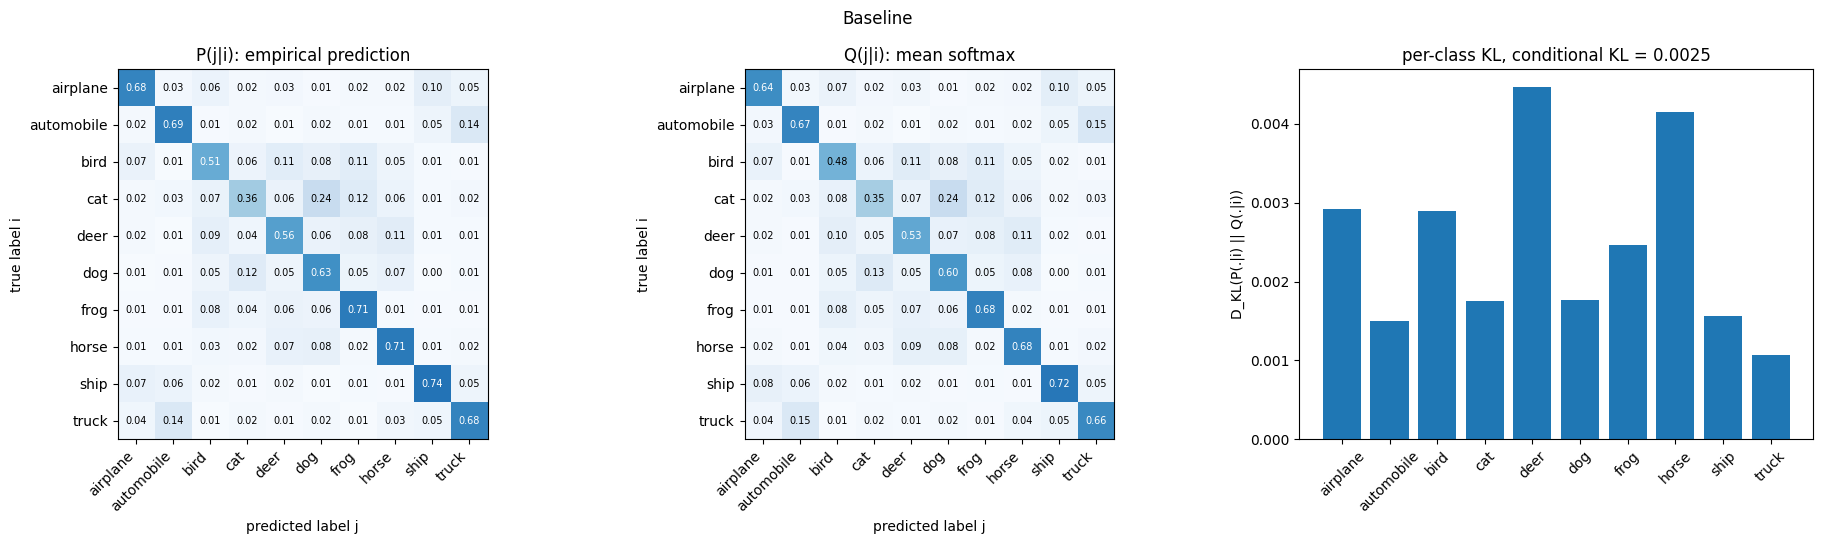

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(baseline_curve['epoch'], baseline_curve['accuracy'], label='test accuracy')
axes[0].plot(baseline_curve['epoch'], baseline_curve['mean_conf'], label='mean confidence (max softmax)')
axes[0].set_xlabel('epoch')
axes[0].set_title('Accuracy vs confidence')
axes[0].legend()
axes[1].plot(baseline_curve['epoch'], baseline_curve['cond_kl'], color='tab:red')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('conditional KL (lower = more reliable)')
axes[1].set_title('Reliability during training')
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(baseline_curve['accuracy'], baseline_curve['cond_kl'], c=baseline_curve['epoch'], cmap='viridis')
fig.colorbar(sc, label='epoch')
ax.set_xlabel('test accuracy')
ax.set_ylabel('conditional KL')
ax.set_title('Accuracy vs reliability (baseline)')
plt.show()

plot_reliability(baseline_probs, y_test, 'Baseline')

### Discussion: accuracy vs reliability

**The baseline did not reach 70%.** With the frozen ImageNet VGG16 base on 32x32 inputs, the validation accuracy
saturates at about 63% (best 0.634), so the 70% stop was never triggered and the head was trained for all
30 epochs. Final test accuracy: 0.628.

**The network is overconfident, and increasingly so as training goes on.**

* Right at initialization the test accuracy is 10% (chance level), yet the mean max-softmax is about 0.88. The large
  magnitude of the VGG16 features produces large logits, so the untrained network already outputs near one-hot
  predictions: high confidence with no accuracy at all.
* During the first ~3 epochs the confidence drops to about 0.76 while the accuracy rises quickly, which narrows the gap.
* After that the accuracy plateaus around 0.62-0.63, but the confidence keeps climbing to 0.85. The gap between
  confidence and accuracy grows from about 0.14 to 0.22.
* This matches the over-fitting in the training log. Train accuracy reaches 99.4% while validation accuracy stays at
  63%, and the validation loss is lowest at epoch 12 (1.354) and rises afterwards (1.654 at epoch 30).

**The conditional KL does not follow the overconfidence.** It first rises from about 0.002 to 0.0075 (epochs 3-9) and
then falls to 0.0025, even though the model becomes more overconfident in that final phase. The reason is how
P and Q are defined:

* Q(j|i) is the class-average of the softmax, and P(j|i) is the class-average of the one-hot argmax.
* When the softmax outputs are close to one-hot, Q equals P, and the KL goes to 0 whatever the accuracy is. The same
  thing happens at initialization: 10% accuracy, but a KL of only 0.002.
* The KL is high only in the middle of training. At that point the outputs are soft but the argmax is already
  decided, so the class-average softmax is flatter than the argmax histogram.

So this metric measures whether the average soft prediction agrees with the average hard prediction for each class.
It does not measure whether the confidence of a prediction matches the chance that it is correct. Below, we
therefore report the confidence-accuracy gap and the NLL alongside the conditional KL.

**Per class.** P and Q are almost identical element by element, so every per-class KL is small (< 0.005). The largest
are deer and horse (about 0.004). Cat is the hardest class (36% accuracy, 24% predicted as dog), yet its KL is low
(about 0.002), which again shows that the KL is not tied to accuracy.

## Ensemble utilities

Members are trained in lockstep, one epoch at a time, so the ensemble can be evaluated after every epoch.
Epoch 0 is the ensemble right after masking, before retraining. At inference the ensemble output is the
average of the members' softmax outputs.

In [8]:
def train_ensemble(kind, n_members=N_MEMBERS, epochs=MEMBER_EPOCHS, kl_lambda=0.0, l2=0.0,
                   conf_branch=False, bootstrap=False, verbose=True):
    rng = np.random.default_rng(SEED + 1)
    members, train_sets = [], []
    for k in range(n_members):
        m = build_head(kind, seed=SEED + k, l2=l2, conf_branch=conf_branch, name=f'{kind}_member_{k}')
        if INIT_FROM_BASELINE:
            copy_head_weights(baseline, m)
        m.compile(optimizer=keras.optimizers.Adam(MEMBER_LR),
                  loss=make_loss(kl_lambda, CONF_BETA if conf_branch else 0.0), metrics=[cls_acc])
        members.append(m)
        idx = rng.choice(len(F_train), len(F_train), replace=True) if bootstrap else np.arange(len(F_train))
        train_sets.append((F_train[idx], Y_train[idx]))

    log = []
    for epoch in range(epochs + 1):
        if epoch > 0:
            for m, (X, Y) in zip(members, train_sets):
                m.fit(X, Y, batch_size=BATCH_SIZE, epochs=1, shuffle=True, verbose=0)
        test_member_probs = [predict_probs(m, F_test) for m in members]
        member_metrics = [evaluate_probs(p, y_test) for p in test_member_probs]
        ens_test = evaluate_probs(np.mean(test_member_probs, axis=0), y_test)
        ens_train = evaluate_probs(ensemble_probs(members, F_train_eval), y_train_eval)
        row = {'epoch': epoch,
               'train_acc': ens_train['accuracy'],
               'test_acc': ens_test['accuracy'],
               'test_cond_kl': ens_test['cond_kl'],
               'test_mean_conf': ens_test['mean_conf'],
               'member_test_acc': np.mean([r['accuracy'] for r in member_metrics]),
               'member_test_cond_kl': np.mean([r['cond_kl'] for r in member_metrics])}
        log.append(row)
        if verbose:
            print(f"epoch {epoch:2d} | ensemble train acc {row['train_acc']:.4f} test acc {row['test_acc']:.4f} "
                  f"cond KL {row['test_cond_kl']:.4f} | members test acc {row['member_test_acc']:.4f} "
                  f"cond KL {row['member_test_cond_kl']:.4f}")
    return members, pd.DataFrame(log)


def summarize(members, name, temperature=1.0):
    member_probs = [predict_probs(m, F_test, temperature) for m in members]
    ens = evaluate_probs(np.mean(member_probs, axis=0), y_test)
    mem = [evaluate_probs(p, y_test) for p in member_probs]
    return {'model': name, **ens,
            'member_acc': float(np.mean([r['accuracy'] for r in mem])),
            'member_cond_kl': float(np.mean([r['cond_kl'] for r in mem])),
            'active_weights_per_member': active_weights(members[0]),
            'n_members': len(members)}


def plot_ensemble_log(log, title):
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
    axes[0].plot(log['epoch'], log['train_acc'], 'o-', label='ensemble, train')
    axes[0].plot(log['epoch'], log['test_acc'], 'o-', label='ensemble, test')
    axes[0].plot(log['epoch'], log['member_test_acc'], 's--', label='single member (mean), test')
    axes[0].set_title('Accuracy (train/test gap = over-fitting)')
    axes[1].plot(log['epoch'], log['test_cond_kl'], 'o-', label='ensemble')
    axes[1].plot(log['epoch'], log['member_test_cond_kl'], 's--', label='single member (mean)')
    axes[1].set_title('Conditional KL on the test set')
    axes[2].plot(log['epoch'], log['test_acc'], 'o-', label='test accuracy')
    axes[2].plot(log['epoch'], log['test_mean_conf'], 'o-', label='mean confidence')
    axes[2].set_title('Ensemble accuracy vs confidence')
    for ax in axes:
        ax.set_xlabel('epoch (0 = right after masking)')
        ax.legend()
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


def fit_temperature(members, grid=np.round(np.arange(0.5, 5.01, 0.1), 2)):
    '''Temperature applied to every member's logits, chosen on the validation set.'''
    val_logits = [run(keras.Model(m.input, m.get_layer('logits').output), F_val) for m in members]
    scan = pd.DataFrame([{'T': T, **evaluate_probs(np.mean([softmax_np(z / T) for z in val_logits], axis=0), y_val)}
                         for T in grid])
    return float(scan.loc[scan[TEMPERATURE_CRITERION].idxmin(), 'T']), scan


def run_improvements(kind, plain_members, label):
    '''Reliability experiments of Sec. 4, run on top of one ensemble type.'''
    rows, ensembles = [], {}

    T, scan = fit_temperature(plain_members)
    print(f'[{label}] temperature chosen on the validation set ({TEMPERATURE_CRITERION}): T = {T:.2f}')
    rows.append(summarize(plain_members, f'{label} + temperature scaling (T={T:.2f})', temperature=T))

    variants = {
        'KL in the loss': dict(kl_lambda=KL_LAMBDA),
        'L2 regularization': dict(l2=L2_WEIGHT),
        'bagging (bootstrap samples)': dict(bootstrap=True),
        'confidence branch': dict(conf_branch=True),
    }
    for vname, kwargs in variants.items():
        t0 = time.time()
        members, log = train_ensemble(kind, verbose=False, **kwargs)
        ensembles[vname] = (members, log)
        rows.append(summarize(members, f'{label} + {vname}'))
        print(f'[{label}] {vname}: test acc {rows[-1]["accuracy"]:.4f}, '
              f'cond KL {rows[-1]["cond_kl"]:.4f} ({time.time() - t0:.0f}s)')
    return pd.DataFrame(rows), ensembles, scan


def plot_temperature_scan(scan, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(scan['T'], scan['cond_kl'])
    axes[0].set_ylabel('conditional KL (validation)')
    axes[1].plot(scan['T'], scan['nll'])
    axes[1].set_ylabel('NLL (validation)')
    for ax in axes:
        ax.set_xlabel('temperature T')
        ax.axvline(1.0, color='gray', ls=':')
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


def plot_comparison(df, title):
    fig, axes = plt.subplots(1, 2, figsize=(16, 0.5 * len(df) + 2))
    y = np.arange(len(df))
    axes[0].barh(y, df['accuracy'])
    axes[0].set_xlim(df['accuracy'].min() - 0.05, min(1.0, df['accuracy'].max() + 0.02))
    axes[0].set_title('Test accuracy')
    axes[1].barh(y, df['cond_kl'], color='tab:red')
    axes[1].set_title('Conditional KL (lower = more reliable)')
    for ax in axes:
        ax.set_yticks(y, df['model'])
        ax.invert_yaxis()
    axes[1].set_yticklabels([])
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

## 4. Task 1: dropout-induced random edges (node removal)

Five copies of the baseline; in each one 80% of the nodes of the two hidden dense layers are removed with a
different random mask (the 10 output nodes are kept). The members are then retrained and averaged as an
ensemble.

epoch  0 | ensemble train acc 0.1904 test acc 0.1783 cond KL 0.2294 | members test acc 0.1372 cond KL 0.1250
epoch  1 | ensemble train acc 0.7140 test acc 0.6640 cond KL 0.0516 | members test acc 0.6387 cond KL 0.0361
epoch  2 | ensemble train acc 0.7472 test acc 0.6799 cond KL 0.0436 | members test acc 0.6559 cond KL 0.0293
epoch  3 | ensemble train acc 0.7731 test acc 0.6855 cond KL 0.0381 | members test acc 0.6599 cond KL 0.0243
epoch  4 | ensemble train acc 0.7958 test acc 0.6900 cond KL 0.0349 | members test acc 0.6598 cond KL 0.0201
epoch  5 | ensemble train acc 0.8173 test acc 0.6912 cond KL 0.0317 | members test acc 0.6592 cond KL 0.0170
epoch  6 | ensemble train acc 0.8340 test acc 0.6925 cond KL 0.0298 | members test acc 0.6567 cond KL 0.0143
epoch  7 | ensemble train acc 0.8514 test acc 0.6936 cond KL 0.0285 | members test acc 0.6537 cond KL 0.0118
epoch  8 | ensemble train acc 0.8657 test acc 0.6930 cond KL 0.0270 | members test acc 0.6489 cond KL 0.0092
epoch  9 | ensemble

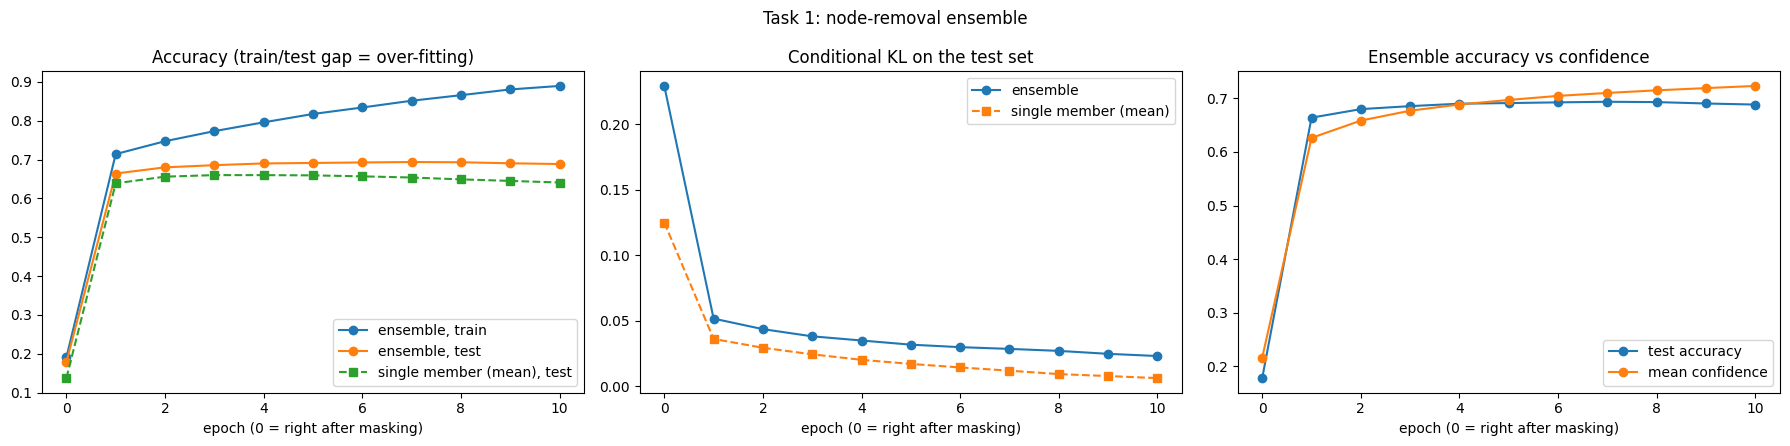

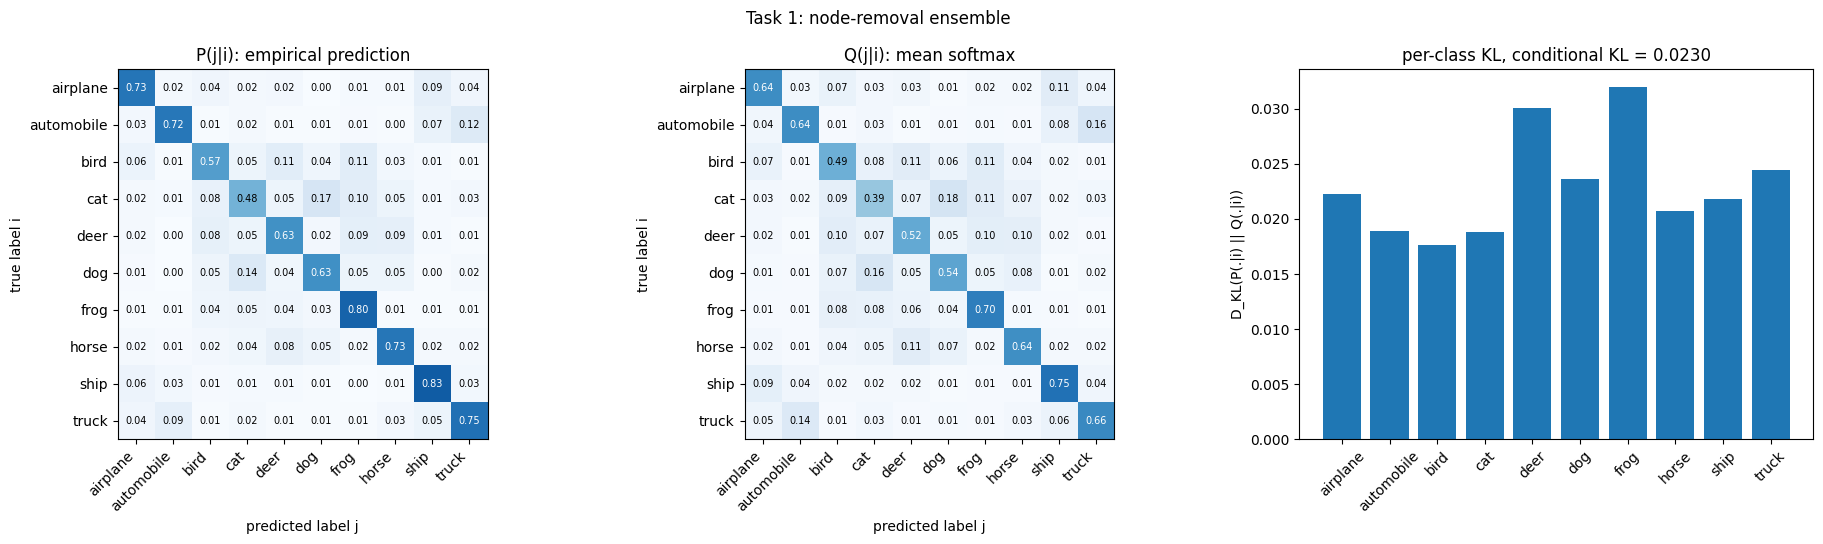

active weights: baseline 396554 | one Task 1 member 58099 | 5 members 290495


,model,accuracy,cond_kl,mean_conf,nll,member_acc,member_cond_kl,active_weights_per_member,n_members
0,baseline (single model),0.6277,0.0025,0.8505,1.7210,0.6277,0.0025,396554,1
1,Task 1 ensemble,0.6884,0.0230,0.7231,0.9527,0.6409,0.0062,58099,5


In [9]:
t1_members, t1_log = train_ensemble('node')
plot_ensemble_log(t1_log, 'Task 1: node-removal ensemble')
t1_probs = ensemble_probs(t1_members, F_test)
plot_reliability(t1_probs, y_test, 'Task 1: node-removal ensemble')

print('active weights: baseline', active_weights(baseline),
      '| one Task 1 member', active_weights(t1_members[0]),
      '| 5 members', N_MEMBERS * active_weights(t1_members[0]))
pd.DataFrame([summarize([baseline], 'baseline (single model)'),
              summarize(t1_members, 'Task 1 ensemble')]).round(4)

### Discussion: Task 1 ensemble

| | test acc | cond. KL | mean conf | conf - acc | NLL |
|---|---|---|---|---|---|
| baseline (1 model) | 0.628 | 0.0025 | 0.851 | +0.22 | 1.721 |
| Task 1 single member (mean) | 0.641 | 0.0062 | | | |
| Task 1 ensemble (5 members) | 0.688 | 0.0230 | 0.723 | +0.03 | 0.953 |

* **Masking and retraining.** Removing 80% of the hidden nodes destroys the baseline: accuracy drops to 18% at epoch 0.
  One epoch of retraining brings it back to 66%.
* **Accuracy.** A single member (102 and 51 hidden units) is already slightly better than the over-fitted baseline.
  Averaging the 5 members adds about 5 points on top (0.641 -> 0.688; the peak is 0.694 at epoch 7).
* **Over-fitting.** The ensemble's train/test gap is 0.89 vs 0.69 = 0.20, against 0.99 vs 0.63 = 0.36 for the
  baseline. The individual members still over-fit: their test accuracy peaks at 0.660 at epoch 3-4, then drops to
  0.641. Meanwhile their KL keeps falling, because their outputs become sharper. The ensemble's test accuracy stays
  flat, so averaging cancels most of the member-level over-fitting.
* **Reliability.**
  * By the handout's conditional KL, the ensemble looks worse than the baseline (0.023 vs 0.0025). Averaging five
    different softmax outputs gives a smoother Q, while P is built from the argmax and stays sharp.
  * By confidence vs accuracy, the ensemble is far better calibrated: the overconfidence gap shrinks from 0.22 to
    0.03, and the NLL drops from 1.72 to 0.95.
  * So the ensemble fixes the overconfidence described in the handout. The conditional KL cannot show this, for
    the reason explained above.
* **Cost.** One member has 58,099 active weights, so the 5 members together have 290,495. That is 73% of the
  baseline's 396,554, i.e. roughly the same computational budget, as required.

### Task 1: improving reliability

Each variant is a new 5-member node-removal ensemble, except temperature scaling, which is applied after
training to the ensemble above:

* temperature scaling: logits divided by T before the softmax, T chosen on the validation set
* KL in the loss: cross-entropy + `KL_LAMBDA` * mini-batch conditional KL
* L1/L2 regularization: L2 penalty `L2_WEIGHT` on the dense kernels
* a different ensemble method: bagging, each member trained on its own bootstrap sample
* extra confidence output: see "Model building blocks"

[Task 1] temperature chosen on the validation set (cond_kl): T = 0.50
[Task 1] KL in the loss: test acc 0.6843, cond KL 0.0177 (58s)
[Task 1] L2 regularization: test acc 0.6894, cond KL 0.0238 (58s)
[Task 1] bagging (bootstrap samples): test acc 0.6810, cond KL 0.0200 (53s)
[Task 1] confidence branch: test acc 0.6914, cond KL 0.0799 (64s)


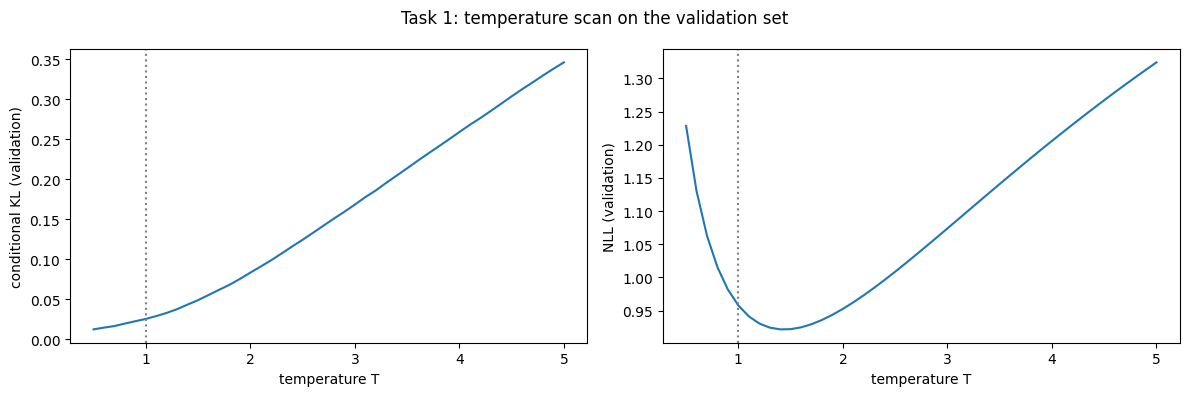

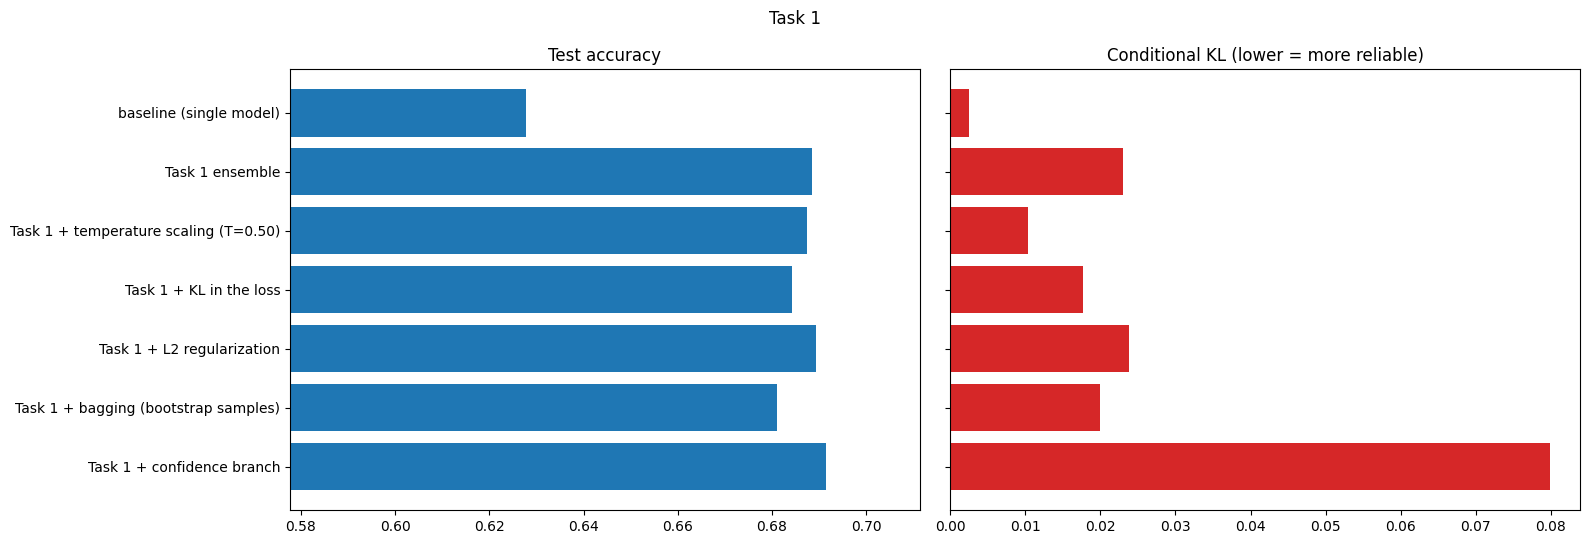

,model,accuracy,cond_kl,mean_conf,nll,member_acc,member_cond_kl,active_weights_per_member,n_members
0,baseline (single model),0.6277,0.0025,0.8505,1.7210,0.6277,0.0025,396554,1
1,Task 1 ensemble,0.6884,0.0230,0.7231,0.9527,0.6409,0.0062,58099,5
2,Task 1 + temperature scaling (T=0.50),0.6875,0.0104,0.7838,1.2288,0.6409,0.0010,58099,5
3,Task 1 + KL in the loss,0.6843,0.0177,0.7412,0.9802,0.6407,0.0043,58099,5
4,Task 1 + L2 regularization,0.6894,0.0238,0.7213,0.9506,0.6412,0.0064,58099,5
5,Task 1 + bagging (bootstrap samples),0.6810,0.0200,0.7238,1.0559,0.6145,0.0020,58099,5
6,Task 1 + confidence branch,0.6914,0.0799,0.6232,0.9920,0.6447,0.0543,58099,5


In [10]:
t1_improved, t1_variants, t1_scan = run_improvements('node', t1_members, 'Task 1')
plot_temperature_scan(t1_scan, 'Task 1: temperature scan on the validation set')

t1_results = pd.concat([pd.DataFrame([summarize([baseline], 'baseline (single model)'),
                                      summarize(t1_members, 'Task 1 ensemble')]), t1_improved],
                       ignore_index=True)
plot_comparison(t1_results, 'Task 1')
t1_results.round(4)

In [11]:
# P/Q matrices of the most reliable Task 1 variant
best = t1_results.loc[t1_results['cond_kl'].idxmin(), 'model']
print('lowest conditional KL:', best)
if 'temperature' in best:
    T_best = float(best.split('T=')[1].rstrip(')'))
    plot_reliability(ensemble_probs(t1_members, F_test, T_best), y_test, best)
elif best.startswith('Task 1 + '):
    plot_reliability(ensemble_probs(t1_variants[best[len('Task 1 + '):]][0], F_test), y_test, best)

lowest conditional KL: baseline (single model)


### Discussion: Task 1 improvements

| Task 1 variant | test acc | cond. KL | mean conf | NLL |
|---|---|---|---|---|
| ensemble | 0.688 | 0.0230 | 0.723 | 0.953 |
| + temperature (T=0.5) | 0.688 | 0.0104 | 0.784 | 1.229 |
| + KL in the loss (lambda=1) | 0.684 | 0.0177 | 0.741 | 0.980 |
| + L2 (1e-4) | 0.689 | 0.0238 | 0.721 | 0.951 |
| + bagging | 0.681 | 0.0200 | 0.724 | 1.056 |
| + confidence branch | 0.691 | 0.0799 | 0.623 | 0.992 |

* **Temperature scaling.**
  * On the validation set, the conditional KL increases monotonically with T. Minimizing it therefore drives T to
    the lower end of the grid (0.5). This *sharpens* the softmax: the KL halves, but the mean confidence rises
    above the accuracy (0.78 vs 0.69) and the NLL gets much worse (0.95 -> 1.23).
  * The NLL on the same validation set is minimized at about T = 1.4. This is the usual calibration result: T > 1
    softens the outputs, consistent with the ensemble being slightly overconfident (0.72 vs 0.69).
  * So, with the handout's metric, temperature scaling works in the opposite direction to what the handout
    describes.
* **KL in the loss.** The KL is lowered by 23% (0.0230 -> 0.0177) at a cost of 0.4 points of accuracy. It does this
  by making the members more confident (0.741), again pushing Q toward the hard P. Only lambda = 1 was tried, so
  the sensitivity to lambda was not measured.
* **L2 regularization.** A weight of 1e-4 has no visible effect on any metric. It is too weak compared with the
  regularization the node removal already provides.
* **Bagging.** Each member sees only about 63% of the distinct training images, so members are weaker (0.615 vs
  0.641). The KL decreases slightly (0.0230 -> 0.0200), but the ensemble accuracy drops by 0.7 points and the NLL gets
  worse (0.953 -> 1.056).
* **Confidence branch.** It gives the best accuracy (0.691) but by far the worst KL (0.080). Mixing with the
  uniform distribution with weight 1 - c puts mass on every class, so Q no longer matches P off the diagonal. The
  mean confidence (0.62) is now *below* the accuracy (0.69): the branch over-corrects into underconfidence.
* **Summary.** Among the variants that keep accuracy intact, the KL loss gives the best trade-off. The lowest KL
  overall is still the single over-fitted baseline (0.0025). This is why the "best variant" cell above selected the
  baseline and did not plot anything.

## 5. Task 2: sparsification of the dense layers (edge removal)

Five copies of the baseline; in each one 80% of the edges of the three dense layers are removed with a
different random mask. The members are retrained and averaged as an ensemble.

epoch  0 | ensemble train acc 0.1432 test acc 0.1408 cond KL 0.6162 | members test acc 0.1202 cond KL 0.3938
epoch  1 | ensemble train acc 0.7047 test acc 0.6657 cond KL 0.0485 | members test acc 0.6522 cond KL 0.0401
epoch  2 | ensemble train acc 0.7410 test acc 0.6810 cond KL 0.0415 | members test acc 0.6659 cond KL 0.0335
epoch  3 | ensemble train acc 0.7731 test acc 0.6845 cond KL 0.0354 | members test acc 0.6694 cond KL 0.0277
epoch  4 | ensemble train acc 0.8005 test acc 0.6880 cond KL 0.0319 | members test acc 0.6697 cond KL 0.0225
epoch  5 | ensemble train acc 0.8258 test acc 0.6879 cond KL 0.0277 | members test acc 0.6690 cond KL 0.0187
epoch  6 | ensemble train acc 0.8494 test acc 0.6905 cond KL 0.0260 | members test acc 0.6650 cond KL 0.0149
epoch  7 | ensemble train acc 0.8693 test acc 0.6905 cond KL 0.0241 | members test acc 0.6619 cond KL 0.0120
epoch  8 | ensemble train acc 0.8861 test acc 0.6901 cond KL 0.0221 | members test acc 0.6583 cond KL 0.0096
epoch  9 | ensemble

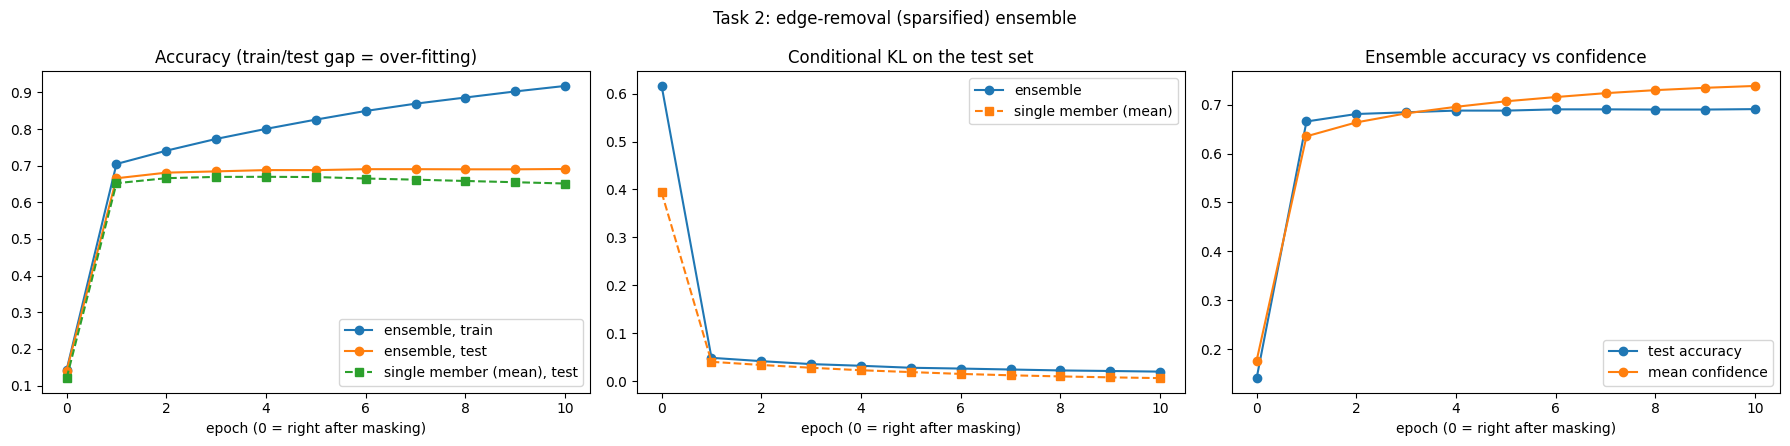

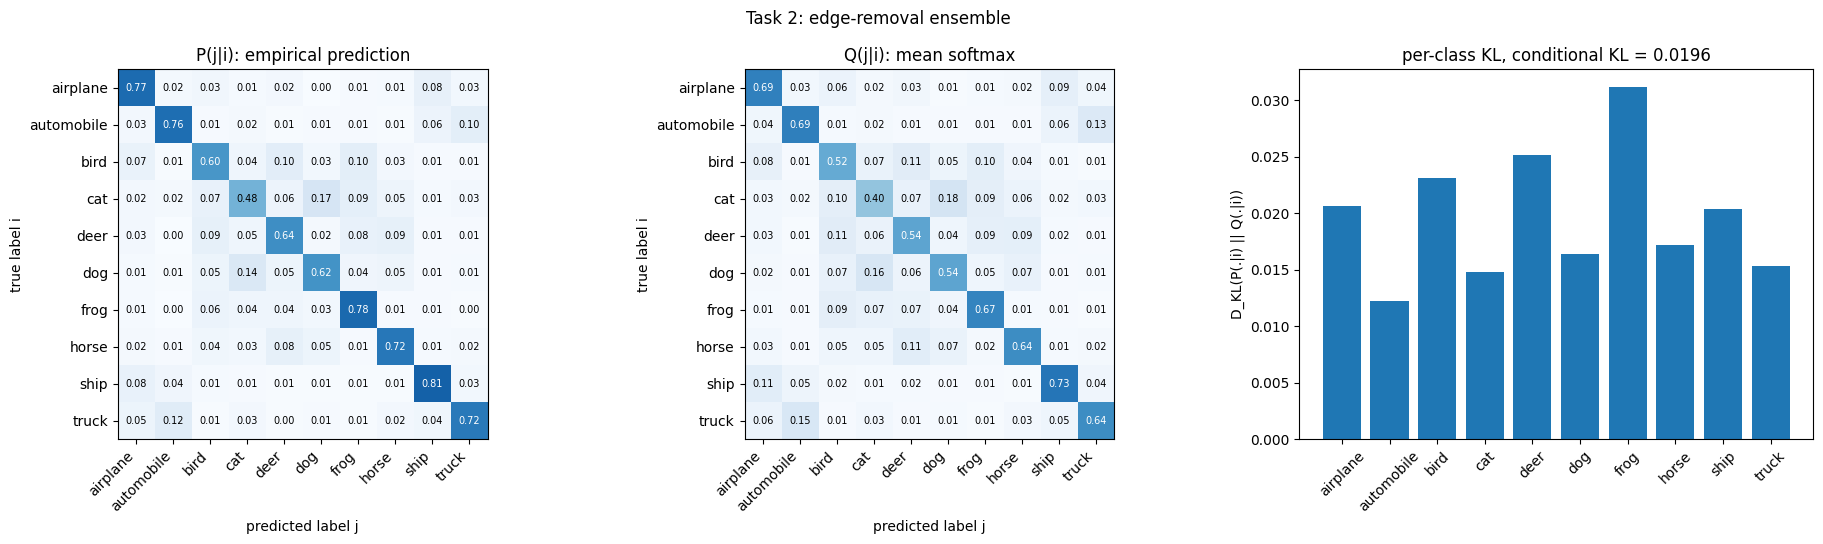

active weights: baseline 396554 | one Task 2 member 79933 | 5 members 399665


,model,accuracy,cond_kl,mean_conf,nll,member_acc,member_cond_kl,active_weights_per_member,n_members
0,baseline (single model),0.6277,0.0025,0.8505,1.7210,0.6277,0.0025,396554,1
1,Task 2 ensemble,0.6910,0.0196,0.7384,0.9502,0.6514,0.0061,79933,5


In [12]:
t2_members, t2_log = train_ensemble('edge')
plot_ensemble_log(t2_log, 'Task 2: edge-removal (sparsified) ensemble')
t2_probs = ensemble_probs(t2_members, F_test)
plot_reliability(t2_probs, y_test, 'Task 2: edge-removal ensemble')

print('active weights: baseline', active_weights(baseline),
      '| one Task 2 member', active_weights(t2_members[0]),
      '| 5 members', N_MEMBERS * active_weights(t2_members[0]))
pd.DataFrame([summarize([baseline], 'baseline (single model)'),
              summarize(t2_members, 'Task 2 ensemble')]).round(4)

### Discussion: Task 2 ensemble

| | test acc | cond. KL | mean conf | conf - acc | NLL |
|---|---|---|---|---|---|
| baseline (1 model) | 0.628 | 0.0025 | 0.851 | +0.22 | 1.721 |
| Task 1 ensemble (nodes) | 0.688 | 0.0230 | 0.723 | +0.03 | 0.953 |
| Task 2 single member (mean) | 0.651 | 0.0061 | | | |
| Task 2 ensemble (edges) | 0.691 | 0.0196 | 0.738 | +0.05 | 0.950 |

* **Masking and retraining.** Removing 80% of the edges drops the accuracy to 14% at epoch 0. It recovers to 67%
  after one epoch.
* **Edge vs node removal.**
  * Individual Task 2 members are about 1 point better than Task 1 members (0.651 vs 0.641). With edge removal
    every hidden node survives, so there is no 102/51-unit bottleneck, and each member keeps more active weights
    (79,933 vs 58,099).
  * The ensembles end up almost equal: 0.691 vs 0.688 accuracy, and a slightly lower KL for Task 2 (0.0196 vs 0.0230).
* **Over-fitting.** Task 2 over-fits a bit more: ensemble train accuracy is 0.918 vs 0.890, and the member test
  accuracy peaks at 0.670 at epoch 4 and then decreases. This is consistent with the larger effective capacity.
  The ensemble test accuracy again stays flat.
* **Reliability.** Same picture as Task 1. The KL is higher than the baseline's, but the ensemble is much better
  calibrated: the confidence gap goes from 0.22 to 0.05, and the NLL from 1.72 to 0.95.
* **Cost.** The 5 sparsified members have 399,665 active weights, 1.01x the baseline: the same budget.

[Task 2] temperature chosen on the validation set (cond_kl): T = 0.50
[Task 2] KL in the loss: test acc 0.6921, cond KL 0.0153 (58s)
[Task 2] L2 regularization: test acc 0.6904, cond KL 0.0201 (56s)
[Task 2] bagging (bootstrap samples): test acc 0.6850, cond KL 0.0177 (53s)
[Task 2] confidence branch: test acc 0.6902, cond KL 0.0574 (66s)


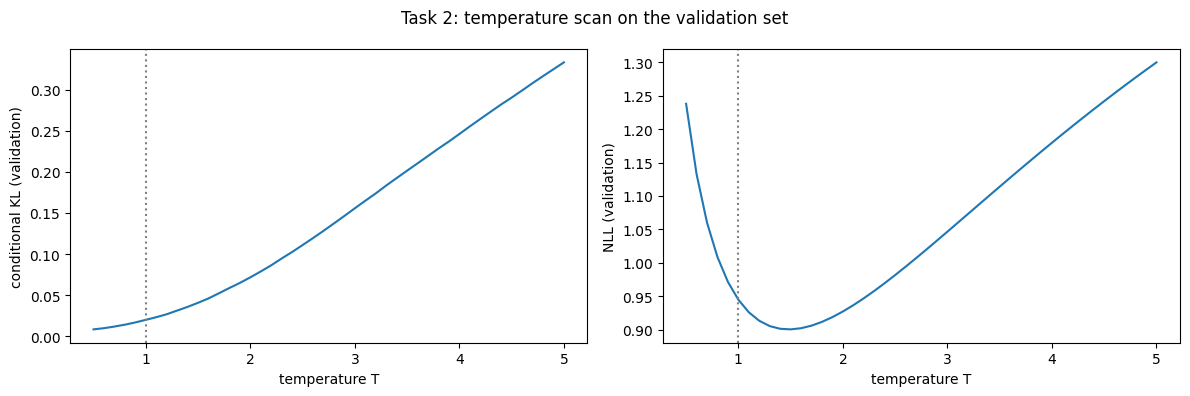

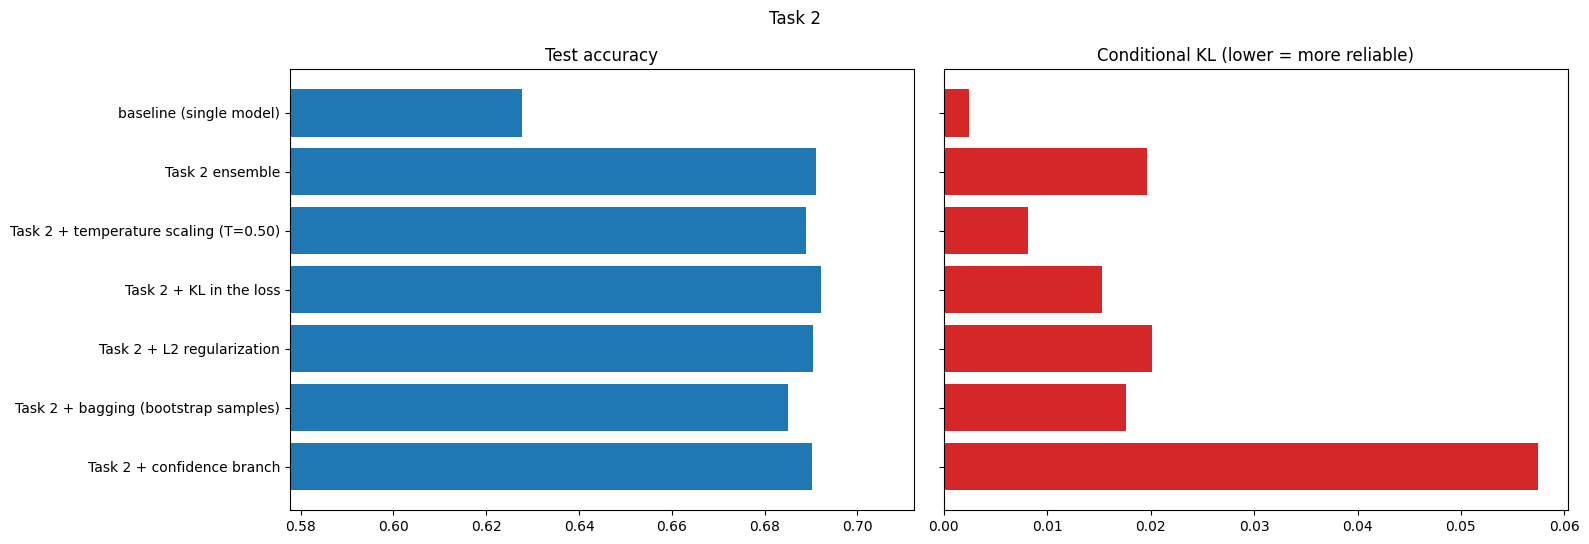

,model,accuracy,cond_kl,mean_conf,nll,member_acc,member_cond_kl,active_weights_per_member,n_members
0,baseline (single model),0.6277,0.0025,0.8505,1.7210,0.6277,0.0025,396554,1
1,Task 2 ensemble,0.6910,0.0196,0.7384,0.9502,0.6514,0.0061,79933,5
2,Task 2 + temperature scaling (T=0.50),0.6890,0.0081,0.7985,1.2546,0.6514,0.0009,79933,5
3,Task 2 + KL in the loss,0.6921,0.0153,0.7593,0.9765,0.6588,0.0048,79933,5
4,Task 2 + L2 regularization,0.6904,0.0201,0.7370,0.9479,0.6538,0.0069,79933,5
5,Task 2 + bagging (bootstrap samples),0.6850,0.0177,0.7392,1.0451,0.6272,0.0023,79933,5
6,Task 2 + confidence branch,0.6902,0.0574,0.6593,0.9560,0.6552,0.0390,79933,5


In [13]:
t2_improved, t2_variants, t2_scan = run_improvements('edge', t2_members, 'Task 2')
plot_temperature_scan(t2_scan, 'Task 2: temperature scan on the validation set')

t2_results = pd.concat([pd.DataFrame([summarize([baseline], 'baseline (single model)'),
                                      summarize(t2_members, 'Task 2 ensemble')]), t2_improved],
                       ignore_index=True)
plot_comparison(t2_results, 'Task 2')
t2_results.round(4)

### Discussion: Task 2 improvements

| Task 2 variant | test acc | cond. KL | mean conf | NLL |
|---|---|---|---|---|
| ensemble | 0.691 | 0.0196 | 0.738 | 0.950 |
| + temperature (T=0.5) | 0.689 | 0.0081 | 0.799 | 1.255 |
| + KL in the loss (lambda=1) | 0.692 | 0.0153 | 0.759 | 0.977 |
| + L2 (1e-4) | 0.690 | 0.0201 | 0.737 | 0.948 |
| + bagging | 0.685 | 0.0177 | 0.739 | 1.045 |
| + confidence branch | 0.690 | 0.0574 | 0.659 | 0.956 |

The techniques behave the same way as in Task 1:

* **Temperature scaling.** The KL-optimal T hits the lower bound 0.5. The NLL-optimal T is again about 1.4-1.5.
* **KL in the loss.** Here it is a pure gain: the KL goes down by 22% (0.0196 -> 0.0153) and the accuracy is slightly
  up (0.692, the best in Task 2).
* **L2 and bagging.** L2 changes nothing. Bagging trades accuracy and NLL for a lower KL.
* **Confidence branch.** It again produces the highest KL and mild underconfidence (0.66 vs 0.69).

## 6. Summary

All results on the test set. The last row is one more ensemble method: the 5 Task 1 members and the 5 Task 2
members averaged together.

saved to /content/PDL_CA2


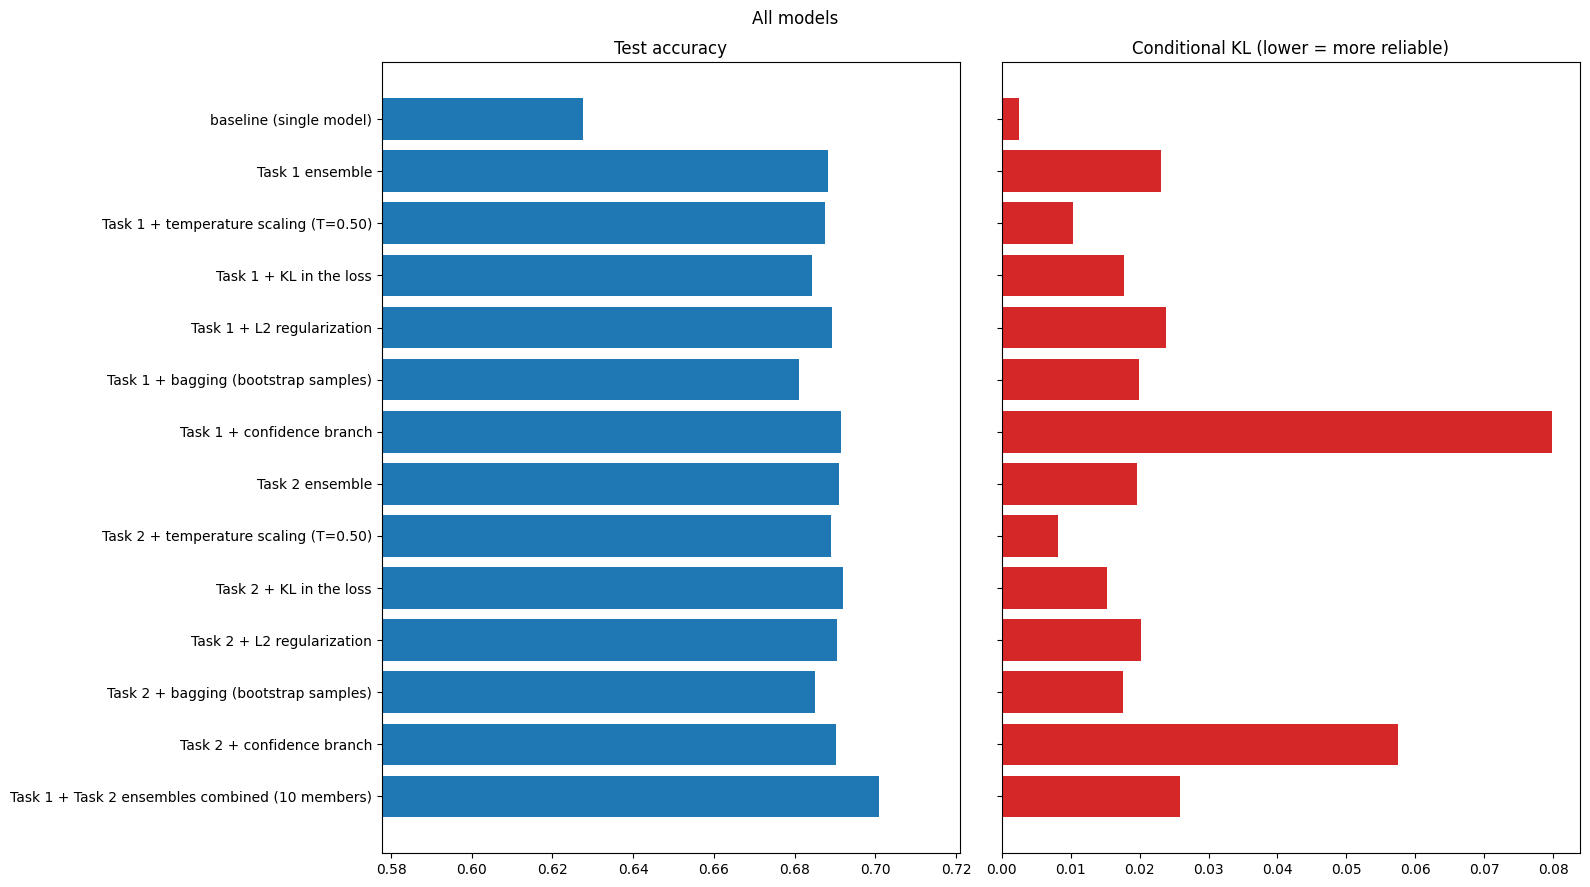

,model,accuracy,cond_kl,mean_conf,nll,member_acc,member_cond_kl,active_weights_per_member,n_members
0,baseline (single model),0.6277,0.0025,0.8505,1.7210,0.6277,0.0025,396554,1
1,Task 1 ensemble,0.6884,0.0230,0.7231,0.9527,0.6409,0.0062,58099,5
2,Task 1 + temperature scaling (T=0.50),0.6875,0.0104,0.7838,1.2288,0.6409,0.0010,58099,5
3,Task 1 + KL in the loss,0.6843,0.0177,0.7412,0.9802,0.6407,0.0043,58099,5
4,Task 1 + L2 regularization,0.6894,0.0238,0.7213,0.9506,0.6412,0.0064,58099,5
5,Task 1 + bagging (bootstrap samples),0.6810,0.0200,0.7238,1.0559,0.6145,0.0020,58099,5
6,Task 1 + confidence branch,0.6914,0.0799,0.6232,0.9920,0.6447,0.0543,58099,5
7,Task 2 ensemble,0.6910,0.0196,0.7384,0.9502,0.6514,0.0061,79933,5
8,Task 2 + temperature scaling (T=0.50),0.6890,0.0081,0.7985,1.2546,0.6514,0.0009,79933,5
9,Task 2 + KL in the loss,0.6921,0.0153,0.7593,0.9765,0.6588,0.0048,79933,5


In [14]:
summary = pd.concat([t1_results, t2_results.iloc[1:],
                     pd.DataFrame([summarize(t1_members + t2_members, 'Task 1 + Task 2 ensembles combined (10 members)')])],
                    ignore_index=True)
summary.to_csv(os.path.join(RESULTS_DIR, 'results.csv'), index=False)
baseline_curve.to_csv(os.path.join(RESULTS_DIR, 'baseline_curve.csv'), index=False)
t1_log.to_csv(os.path.join(RESULTS_DIR, 'task1_log.csv'), index=False)
t2_log.to_csv(os.path.join(RESULTS_DIR, 'task2_log.csv'), index=False)
print('saved to', RESULTS_DIR)

plot_comparison(summary, 'All models')
summary.round(4)

## Conclusions

1. **Overconfidence of the baseline.** The baseline dense head over-fits heavily: 99% train vs 63% test accuracy.
   Its confidence (0.85) is far above its accuracy (0.63), and the gap widens during training. At initialization it
   already reports 0.88 confidence at 10% accuracy.
2. **Ensembles improve accuracy and remove the overconfidence.**
   * Five members with only 20% of the nodes (Task 1) or 20% of the edges (Task 2) improve test accuracy by about 6
     points over the baseline (0.688 / 0.691 vs 0.628), with a similar budget (73% / 101% of the baseline's active
     weights).
   * They reduce over-fitting (train/test gap 0.20-0.23 vs 0.36).
   * They almost close the confidence gap (+0.03 / +0.05 vs +0.22) and nearly halve the NLL (0.95 vs 1.72).
   * Combining the two ensembles (10 members) gives the best accuracy (0.701) and the best NLL (0.903).
3. **Edge vs node removal.** Edge removal (sparsification) gives stronger individual members than node removal,
   because no hidden layer is reduced to a bottleneck. After ensembling the two are nearly equivalent.
4. **The conditional KL of the handout rewards sharp outputs, not calibrated ones.**
   * If the softmax outputs are one-hot, then Q = P and the KL is 0, whatever the accuracy.
   * As a result:
     * the over-fitted baseline has the lowest KL of all models (0.0025);
     * averaging members raises the KL;
     * minimizing it over the temperature always selects the sharpest T tested (0.5), even though the NLL-optimal
       temperature is T of about 1.4 > 1, as the handout anticipates.
   * The KL is informative only together with an accuracy- or likelihood-based measure. Here, the
     confidence-accuracy gap and the NLL tell the opposite story.
5. **Improvement techniques.**
   * Adding the conditional KL to the loss is the most useful: KL -22% in both tasks with at most 0.4 points of
     accuracy lost (none in Task 2).
   * Bagging lowers the KL but costs accuracy.
   * L2 at 1e-4 has no effect.
   * The confidence branch slightly improves accuracy but overshoots into underconfidence.